# QLoRA Tuning using PEFT from Hugging Face

<!-- ### Introduction to Quantization & Fine-tune a Quantized Model -->




<div style="border:1px solid #ccc; border-radius:6px; padding:12px;">

<br>
<b>About</b><br><br>

This notebook is derived from the following notebook, with modifications and extensions: https://github.com/AI-Engineering-bootcamp/ai-eng-nbs-public/blob/master/qlora-tuning-using-peft-from-hugging-face.ipynb
</div>


<br>
<br>

<div style="border:5px solid orange; border-radius:6px; padding:12px;">

<br>
<b>Warning</b><br><br>

The code in this notebook doesn't work in the current version of Google Colab.

(for the code, use the notebooks we've just sent you on Slack)

</div>

<br>

# 📌 Recommendations to run this notebook 

This demo includes LoRA model training, which can take some time to complete.
- **Run in [Google Colab](https://colab.research.google.com/) for GPU access.**<br>
- **Recommended workflow:** Before reading through the explanations and code, run all cells first so that the training process starts in the background. You can then explore the notebook while the model is being trained.


In [1]:
import torch

if torch.cuda.is_available():
    print(f"✅ GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected. For faster training, consider running this notebook on Google Colab with a GPU runtime.")
    print(" On Google Colab, go to: Runtime > Change runtime type > Hardware accelerator > GPU")


✅ GPU is available: Tesla T4


<br>

## Brief Introduction to Quantization
The main idea of quantization is simple: Reduce the precision of floating-point numbers, which normally occupy 32 bits, to integers of 8 or even 4 bits.

This reduction occurs in the model’s parameters, specifically in the weights of the neural layers, and in the activation values that flow through the model’s layers.

This means that we not only achieve an improvement in the model’s storage size and memory consumption but also greater agility in its calculations.

Naturally, there is a loss of precision, but particularly in the case of 8-bit quantization, this loss is minimal.



## Let's see a example of a quantized number.

In reality, what I want to examine is the precision loss that occurs when transitioning from a 32-bit number to a quantized 8/4-bit number and then returning to its original 32-bit value.

First, I'm going to create a function to quantize and another to unquantize.

In [2]:
#Importing necessary libraries
import numpy as np
import math
import matplotlib.pyplot as plt

In [3]:
#Functions to quantize and unquantize
def quantize(value, bits=4):
    quantized_value = np.round(value * (2**(bits - 1) - 1))
    return int(quantized_value)

def unquantize(quantized_value, bits=4):
    value = quantized_value / (2**(bits - 1) - 1)
    return float(value)

Quatizied values:

In [4]:
quant_4 = quantize(0.622, 4)
print (quant_4)
quant_8 = quantize(0.622, 8)
print(quant_8)

4
79


Unquantized values:

In [5]:
unquant_4 = unquantize(quant_4, 4)
print(unquant_4)
unquant_8 = unquantize(quant_8, 8)
print(unquant_8)

0.5714285714285714
0.6220472440944882


If we consider that the original number was 0.622, it can be said that 8-bit quantization barely loses precision, and the loss from 4-bit quantization is manageable.

In [6]:
x = np.linspace(-1, 1, 50)
y = [math.cos(val) for val in x]


y_quant_8bit = np.array([quantize(val, bits=8) for val in y])
y_unquant_8bit = np.array([unquantize(val, bits=8) for val in y_quant_8bit])

y_quant_4bit = np.array([quantize(val, bits=4) for val in y])
y_unquant_4bit = np.array([unquantize(val, bits=4) for val in y_quant_4bit])


Let’s plot a curve with the unquantized values of a cosine.


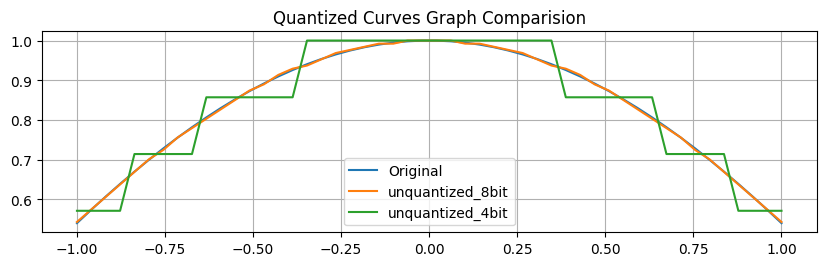

In [7]:
plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(x, y, label="Original")
plt.plot(x, y_unquant_8bit, label="unquantized_8bit")
plt.plot(x, y_unquant_4bit, label="unquantized_4bit")
plt.legend()
plt.title("Quantized Curves Graph Comparision")
plt.grid(True)

<br>
<br>
<br>


Interpreting the Quantized Curves Comparison:

This chart uses the cosine function as a simple, smooth example to illustrate the effects of quantization -the cosine function is commonly used in educational demonstrations because its shape makes quantization errors easy to visualize, real-world quantization —such as in large language models— is typically evaluated using error metrics (e.g., MSE) and model performance rather than function plots. 

In this graph, the x-axis represents the input values (50 evenly spaced points from −1 to 1) passed to the cosine function, while the y-axis represents the corresponding output values, y=cos(x). Comparing the curves shows how closely the quantized values approximate the original function.

- Blue (Original): The true cosine curve with no quantization.
    - Note: the blue (original) curve is almost completely hidden beneath the orange (8-bit) curve because the quantization error is so small that the two curves overlap almost perfectly.
- Orange (8-bit): Nearly identical to the original, indicating minimal quantization error.
- Green (4-bit): Shows a stair-step pattern because fewer bits provide fewer representable values, causing nearby values to be rounded to the same level.
Despite the visible loss of precision in the 4-bit curve, it still captures the overall shape of the original function, illustrating the key trade-off of quantization: reduced precision in exchange for lower memory usage and faster computation.


<br>
<br>
<br>

As you can see, the difference between the 8-bit and the original values is minimal. However, we need to use 4-bit quantization if we want to load the 7B Model into a 16GB GPU without problems.

<br>
<br>
<br>

## LoRA vs. QLoRA

- **LoRA (Low-Rank Adaptation)** fine-tunes a pretrained model by freezing its original weights and training only a small set of low-rank adapter matrices. The base model is commonly loaded in FP16/BF16, resulting in moderate memory requirements.
- **QLoRA (Quantized LoRA)** follows the same approach but first loads the frozen base model in a quantized format, commonly 4-bit. The LoRA adapters remain in higher precision and are the only trainable parameters. This significantly reduces GPU memory usage while maintaining performance close to standard LoRA.

<br>
<br>
<br>

### QLoRA. Fine-tuning a 4-bit Quantized Model using LoRA.
We are going to fine-tune with LoRA a 7B Model Quantizated to 4 bits.

### Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [8]:
!pip install -q --upgrade accelerate bitsandbytes trl peft transformers datasets


I'm going to download the peft and Transformers libraries from their repositories on GitHub instead of using pip. This is not strictly necessary, but this way, you can get the newest versions of the libraries with support for newer models. If you want to check one of the latest models, you can use this trick.


In [9]:
#Install the latest versions of peft & transformers library recommended
#if you want to work with the most recent models
#!pip install -q git+https://github.com/huggingface/peft.git
#!pip install -q git+https://github.com/huggingface/transformers.git

From the Transformers library, we import the necessary classes to load the model and the tokenizer.

The notebook is ready to work with different Models I tested it with models from the Bloom Family and Llama-3.

I recommend you to test different models.

In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig
import torch


## Hugging Face login

The `meta-llama/Meta-Llama-3-8B` model is a **gated model**, so you need permission from Hugging Face before you can download it.

You need to do **two things**:

1. **Accept the model's license**

   * Open the [`meta-llama/Meta-Llama-3-8B` page](https://huggingface.co/meta-llama/Meta-Llama-3-8B).
   * Log in and accept the license.

2. **Create a Hugging Face token**

   * Go to [Hugging Face Settings → Access Tokens](https://huggingface.co/settings/tokens).
   * Create a token with **Read** access.
   * Use the **same account** that accepted the model's license.


**If you are using Colab in your browser**:
- Add the token as a secret named `HF_TOKEN` (**🔑 Secrets → Add new secret**) and enable **Notebook access**.

**If you are using the Colab extension in VS Code**:
- The notebook runs on a Colab server, but Colab Secrets are not available through VS Code. The next cell will prompt you for your token instead.

<br>

> IMPORTANT: **Never save your token in the notebook or commit it to Git ⚠️**

<br>

In [11]:
from huggingface_hub import login
import os

# Prefer an existing env var, then a Colab secret named HF_TOKEN, otherwise prompt.
token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")

if not token:
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")
    except Exception:
        token = None

if token:
    login(token=token)
else:
    login()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


## Load Model

In [12]:
#Use any model you want, if you want to do some fast test, just use the smallest one.

#model_name = "bigscience/bloomz-560m"
#model_name="bigscience/bloom-1b1"
#model_name = "bigscience/bloom-7b1"
#target_modules = ["query_key_value"]

model_name = "meta-llama/Meta-Llama-3-8B"
target_modules = ["q_proj", "v_proj"]

To load the model, we need a configuration class that specifies how we want the quantization to be performed. We’ll achieve this with the BitesAndBytesConfig from the Transformers library.

In [13]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

We are specifying the use of 4-bit quantization and also enabling double quantization to reduce the precision loss.

For the bnb_4bit_quant_type parameter, I've used the recommended value in the paper [QLoRA: Efficient Finetuning of Quantized LLMs.](https://arxiv.org/abs/2305.14314)

Now, we can go ahead and load the model.

In [14]:
device_map = {"": 0}
foundation_model = AutoModelForCausalLM.from_pretrained(model_name,
                    quantization_config=bnb_config,
                    device_map=device_map,
                    use_cache = False)



OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3-8B.
403 Client Error. (Request ID: Root=1-6abf4fa3-09e3d5bb015f01324f613a25;81ad2075-1c03-4723-87f3-9e7ffdc6200e)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3-8B/resolve/8cde5ca8380496c9a6cc7ef3a8b46a0372a1d920/config.json.
Access to model meta-llama/Meta-Llama-3-8B is restricted and you are not in the authorized list. Visit https://huggingface.co/meta-llama/Meta-Llama-3-8B to ask for access.

Now we have the quantized version of the model in memory. Yo can try to load the unquantized version to see if it's possible.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [ ]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=False, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [ ]:
#Inference original model
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

The answer is good enough, the models used is a really well trained Model. But we will try to improve the quality with a sort fine-tuning process.


## Preparing the Dataset.
The Dataset useds is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [ ]:
from datasets import load_dataset
dataset = "fka/awesome-chatgpt-prompts"

#Create the Dataset to create prompts.
data = load_dataset(dataset)

data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)
train_sample = data["train"].select(range(50))

del data
train_sample = train_sample.remove_columns('act')

display(train_sample)

In [ ]:
print(train_sample[:1])

## Fine-Tuning.
The first step will be to create a LoRA configuration object where we will set the variables that specify the characteristics of the fine-tuning process.

In [ ]:
# TARGET_MODULES
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

import peft
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16, #As bigger the R bigger the parameters to train.
    lora_alpha=16, # a scaling factor that adjusts the magnitude of the weight matrix. It seems that as higher more weight have the new training.
    target_modules=target_modules,
    lora_dropout=0.05, #Helps to avoid Overfitting.
    bias="none", # this specifies if the bias parameter should be trained.
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the value more parameters are trained, but it means that the model will be able to learn more complicated relations between inputs and outputs.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_alpha**. Ad bigger the number more weight have the LoRA activations, it means that the fine-tuning process will have more impac as bigger is this value.

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

In [ ]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [ ]:
# Training arguments are now configured via SFTConfig in the SFTTrainer cell below.


Now we can train the model.
To train the model we need:


*   The Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.
* The LoRA config.





In [ ]:
from trl import SFTTrainer, SFTConfig

tokenizer.pad_token = tokenizer.eos_token
sft_config = SFTConfig(
    output_dir=output_directory,
    auto_find_batch_size=True,
    learning_rate=2e-4,
    num_train_epochs=5,
    dataset_text_field="prompt",
)
trainer = SFTTrainer(
    model=foundation_model,
    args=sft_config,
    train_dataset=train_sample,
    peft_config=lora_config,
    processing_class=tokenizer,
)
trainer.train()


In [ ]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")


In [ ]:
#Save the model.
trainer.model.save_pretrained(peft_model_path)

In [ ]:
#In case you are having memory problems uncomment this lines to free some memory
import gc
import torch
del foundation_model
del trainer
del train_sample
torch.cuda.empty_cache()
gc.collect()

## Inference with the pretrained model

In [ ]:
#import peft
from peft import AutoPeftModelForCausalLM, PeftConfig
#import os

device_map = {"": 0}
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")
peft_model_path = os.path.join(output_directory, f"lora_model")


In [ ]:
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
#Load the Model.
loaded_model = AutoPeftModelForCausalLM.from_pretrained(
                                        peft_model_path,
                                        #torch_dtype=torch.bfloat16,
                                        is_trainable=False,
                                        #load_in_4bit=True,
                                        quantization_config=bnb_config2,
                                        device_map = 'cuda')

## Inference the fine-tuned model.

In [ ]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

The result is really good. Let's compare the answer of the pre-trained model with the fine-tuned one:

* **Pretrained Model**: 'I want you to act as a motivational coach. \xa0You are going on an adventure with me, and I need your help.\nWe will be traveling through the land of “What If.” \xa0 This is not some place that exists in reality; it’s more like one those places we see when watching'

* **Fine-Tuned Model**: 'I want you to act as a motivational coach.  I will provide some information about an individual or group of people who need motivation, and your role is help them find the inspiration they require in order achieve their goals successfully! You can use techniques such as positive reinforcement, visualization exercises etc., depending on what'

As you can see, the result is really similar to the samples contained in the dataset used to fine-tune the model. And we only trained the model for some epochs and with a really small number of rows.

# Continue Learning
Please, play with all the variables in the notebook and drive your own experiments and get your conclusions. Changes in the ***lora_alpha*** can have a big effect in the results.

You can change the rest of **lora_config** values, maybe you can achieve a better result in less epochs, saving time and money in your projects.

